In [1]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from video_analyzer import (
    find_top_changed_frames,
    save_frame_change_counts_to_csv,
    export_results_to_csv,
    save_frames_as_images,
)
import seaborn as sns

In [2]:
video_path = '12Feb2022\VID_002.MOV'
diff_threshold = 50  # Tweak this value as needed
top_n = 10


### top 10 frames with the most changes

In [3]:

results = find_top_changed_frames(
    video_path=video_path,
    top_n=top_n,
    diff_threshold=diff_threshold,
)

csv_path = export_results_to_csv(results, 'output/top_changed_frames.csv')
saved_images = save_frames_as_images(video_path, results, output_dir='output')

print(f'Saved CSV: {csv_path}')
print(f'Saved {len(saved_images)} frame images in output folder.')

Saved CSV: output\top_changed_frames.csv
Saved 1 frame images in output folder.


In [4]:
df = pd.DataFrame(results, columns=['Changed Pixels', 'Frame Number', 'Timestamp (Seconds)'])
df = df[['Changed Pixels', 'Timestamp (Seconds)', 'Frame Number']]
print("head of the dataframe:", df.head())

head of the dataframe:    Changed Pixels  Timestamp (Seconds)  Frame Number
0            4729            85.266667          2558


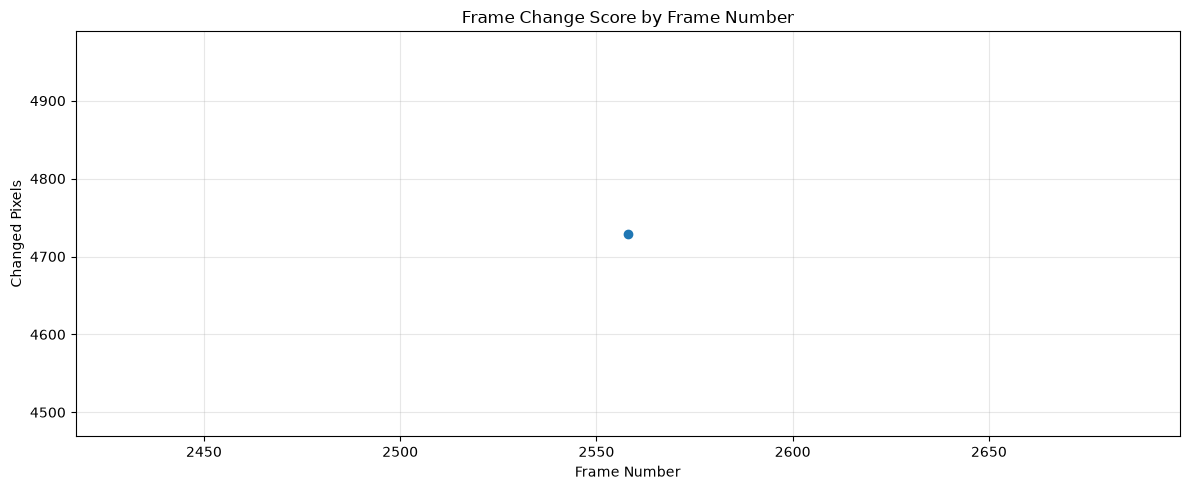

In [5]:
plot_df = df.sort_values('Frame Number')

plt.figure(figsize=(12, 5))
plt.plot(plot_df['Frame Number'], plot_df['Changed Pixels'], marker='o', linewidth=1.5)
plt.title('Frame Change Score by Frame Number')
plt.xlabel('Frame Number')
plt.ylabel('Changed Pixels')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### all frames with timestamp

In [6]:
save_frame_change_counts_to_csv(video_path = video_path,
                                   diff_threshold = diff_threshold,
                                   csv_path = 'output/all_frame_change_counts.csv')

WindowsPath('output/all_frame_change_counts.csv')

In [7]:
# load the CSV file and display the first few rows
all_changes_df = pd.read_csv('output/all_frame_change_counts.csv')

rows = 25
for n in range(0, len(all_changes_df), rows):
    print(all_changes_df.iloc[n:n+rows])

    Frame Number  Timestamp (Seconds)  Changed Pixels
0              0             0.000000               0
1              1             0.033333               0
2              2             0.066667               0
3              3             0.100000             302
4              4             0.133333               0
5              5             0.166667               0
6              6             0.200000               0
7              7             0.233333               0
8              8             0.266667               0
9              9             0.300000               0
10            10             0.333333               0
11            11             0.366667               0
12            12             0.400000               0
13            13             0.433333               0
14            14             0.466667               0
15            15             0.500000               0
16            16             0.533333               0
17            17            

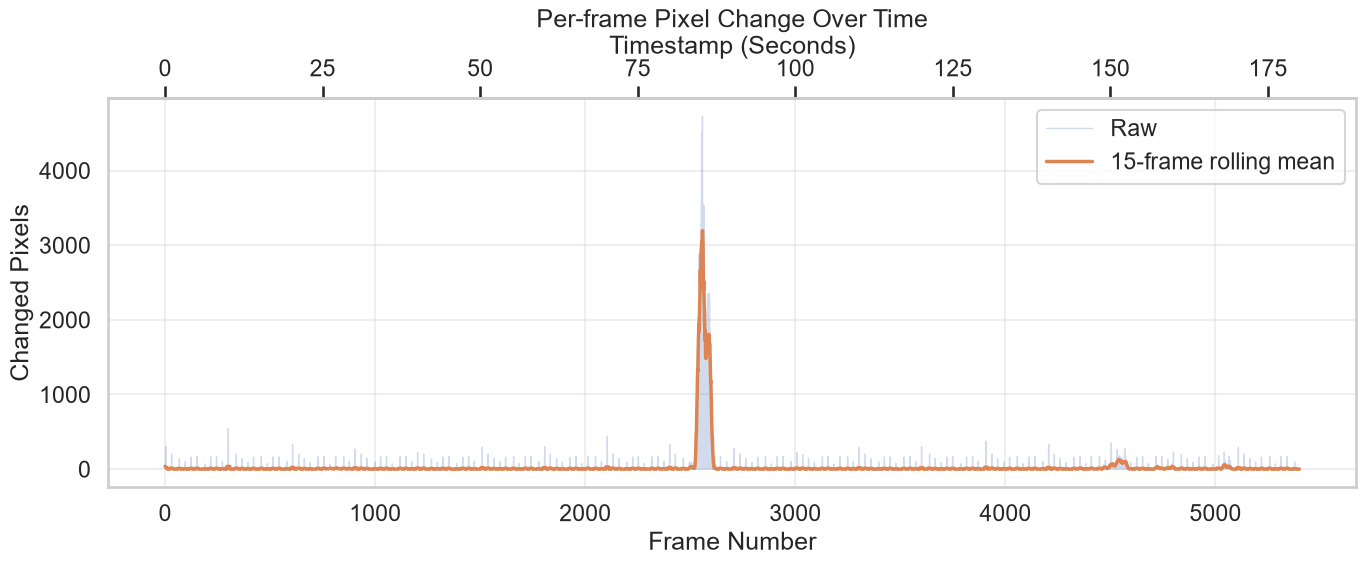

In [8]:
# Better seaborn visualization for frame-by-frame change data
sns.set_theme(style='whitegrid', context='talk')

plot_df = all_changes_df.sort_values('Frame Number').copy()
plot_df['Rolling Mean'] = plot_df['Changed Pixels'].rolling(window=15, center=True, min_periods=1).mean()

fps_estimate = 1 / plot_df['Timestamp (Seconds)'].diff().median() if len(plot_df) > 1 else 1
frame_to_time = lambda frame_number: frame_number / fps_estimate
time_to_frame = lambda time_seconds: time_seconds * fps_estimate

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=plot_df, x='Frame Number', y='Changed Pixels', alpha=0.25, linewidth=1, label='Raw', ax=ax)
sns.lineplot(data=plot_df, x='Frame Number', y='Rolling Mean', linewidth=2.5, label='15-frame rolling mean', ax=ax)

ax.set_title('Per-frame Pixel Change Over Time')
ax.set_xlabel('Frame Number')
ax.set_ylabel('Changed Pixels')
ax.grid(True, alpha=0.3)

secondary_ax = ax.secondary_xaxis('top', functions=(frame_to_time, time_to_frame))
secondary_ax.set_xlabel('Timestamp (Seconds)')

fig.tight_layout()
plt.show()